# Quiz 2

**This is an individual assignment.**

---

For the analytical problems below, you can:

1. write your answers in markdown cells with $\LaTeX$, *or*
2. Embed pictures with your handwritten answers inside the Notebook, *or*
3. ```push``` a single pdf to your repository with all handwritten answers.

---

# Exercise 1 (3 points)

**Suppose you have a training set with $N$ data points $\{x_i\}_{i=1}^N$, where $x_i\in\mathbb{R}$. Assume the samples are independent and identically distributed (i.i.d.), and each sample is drawn from a Gaussian random variable with *known* mean $\mu$ and *unknown* variance $\sigma^2$. The probability density function is defined as:**

\begin{align*}
    p(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
\end{align*}

**where $\mu,\sigma>0$.**

**Moreover, consider the Inverse Gamma as the prior probability on the hyperparameter $\sigma^2$,**

\begin{align*}
    p(x|\alpha, \beta) = \frac{\beta^{\alpha}}{\Gamma(\alpha)}x^{-\alpha-1}\exp\left(-\frac{\beta}{x}\right)
\end{align*}

**where $\alpha,\beta>0$.**

**Answer the following questions:**

1. (1 point) **Derive the maximum likelihood estimate (MLE) for the parameter $\sigma^2$. Show your work.**

The observed data likelihood is:

\begin{align*}
    \mathcal{L}^0 = \prod_{i=1}^N \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
\end{align*}

The log-likelihood is given by:

\begin{align*}
    \mathcal{L} &= \ln{\mathcal{L}^0}\\
    &= \sum_{i=1}^N \left( \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}} \right) -\frac{(x_i-\mu)^2}{2\sigma^2} \right)\\
    &= \sum_{i=1}^N \left( \ln(1) - \ln(\sqrt{2\pi\sigma^2})-\frac{(x_i-\mu)^2}{2\sigma^2}  \right)\\
    &= \sum_{i=1}^N \left( -\frac{1}{2}\ln(2\pi\sigma^2)-\frac{(x_i-\mu)^2}{2\sigma^2}  \right)\\
    &= \sum_{i=1}^N \left( -\frac{1}{2}\ln(2\pi) -\frac{1}{2}\ln(\sigma^2)-\frac{(x_i-\mu)^2}{2\sigma^2}  \right)
\end{align*}

We can now find the MLE estimation for $\beta$:

\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \beta} = 0 &\iff \sum_{i=1}^N \left( -\frac{1}{2}\frac{1}{\sigma^2} + \frac{2(x_i-\mu)^2}{(2\sigma^2)^2}\right) =0\\
    &\iff \sum_{i=1}^N \left(-1 + \frac{(x_i-\mu)^2}{\sigma^2}\right) =0\\ 
    &\iff \frac{1}{\sigma^2} \sum_{i=1}^N (x_i-\mu)^2 = N\\
    &\iff \sigma^2 = \frac{\sum_{i=1}^N (x_i-\mu)^2}{N}
\end{align*}

As expected, the MLE solution for the variance, $\sigma^2$, is the (biased) sample variance estimator.

2. (1 point) **Derive the maximum a posteriori (MAP) estimate for the parameter $\sigma^2$. Show your work.**

The observed data likelihood for MAP is:

\begin{align*}
    \mathcal{L}^0 &= \left[\prod_{i=1}^N \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)\right] \frac{\beta^{\alpha}}{\Gamma(\alpha)}{\sigma^2}^{(-\alpha-1)}\exp\left(-\frac{\beta}{\sigma^2}\right)\\
    &= \prod_{i=1}^N \left[(2\pi)^{-1/2} {\sigma^2}^{-1/2} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)\right]\frac{\beta^{\alpha}}{\Gamma(\alpha)}{\sigma^2}^{(-\alpha-1)}\exp\left(-\frac{\beta}{\sigma^2}\right)\\
    &\propto \prod_{i=1}^N \left[{\sigma^2}^{-1/2} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)\right]{\sigma^2}^{(-\alpha-1)}\exp\left(-\frac{\beta}{\sigma^2}\right)\\
    &= {\sigma^2}^{-N/2} \exp\left(\sum_{i=1}^N-\frac{(x_i-\mu)^2}{2\sigma^2}\right) {\sigma^2}^{(-\alpha-1)}\exp\left(-\frac{\beta}{\sigma^2}\right)\\
    &= {\sigma^2}^{-N/2-\alpha-1} \exp\left(\left(\sum_{i=1}^N-\frac{(x_i-\mu)^2}{2\sigma^2}\right)  -\frac{\beta}{\sigma^2}\right) \\
    &= {\sigma^2}^{- (N/2+\alpha)-1} \exp\left(\left(\sum_{i=1}^N-\frac{(x_i-\mu)^2}{2\sigma^2}\right)  -\frac{\beta}{\sigma^2}\right) 
\end{align*}

The log-likelihood is given by:

\begin{align*}
    \mathcal{L} &= \ln{\mathcal{L}^0}\\
    &= \left(-\frac{N}{2}-\alpha-1\right)\sigma^2 - \sum_{i=1}^N \left(\frac{(x_i-\mu)^2}{2\sigma^2} \right)-\frac{\beta}{\sigma^2}
\end{align*}

We can now find the MAP estimation for $\beta$:

\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \beta} = 0 & \iff \left(-\frac{N}{2}-\alpha-1\right)\frac{1}{\sigma^2} -\sum_{i=1}^N \left(-\frac{2(x_i-\mu)^2}{(2\sigma^2)^2}  \right)+ \frac{\beta}{(\sigma^2)^2} =  0\\
    &\iff \left(-\frac{N}{2}-\alpha-1\right) +\sum_{i=1}^N \left(\frac{(x_i-\mu)^2}{2\sigma^2} \right) + \frac{\beta}{\sigma^2}  =  0\\
    &\iff \left(-\frac{N}{2}-\alpha-1\right) +\frac{1}{\sigma^2}\left[\sum_{i=1}^N \left(\frac{(x_i-\mu)^2}{2} \right)+ \beta \right] =  0\\
    &\iff \sigma^2 = \frac{\sum_{i=1}^N \left(\frac{(x_i-\mu)^2}{2} \right)+\beta}{\frac{N}{2}+\alpha+1}
\end{align*}

3. (1 point) **Show that the Inverse Gamma forms a conjugate prior with the Gaussian likelihood, and write down the pseudo-code for the online update of the prior parameters.**

We showed in the weighted data likelihood in (2), as see below,

\begin{align*}
    \mathcal{L}^0 &\propto {\sigma^2}^{- (N/2+\alpha)-1} \exp\left(\left(\sum_{i=1}^N-\frac{(x_i-\mu)^2}{2\sigma^2}\right)  -\frac{\beta}{\sigma^2}\right) 
\end{align*}

Its parametric form is identical to an Inverse Gamma by a scaling factor. Thus, the Inverse Gamma and the Gaussian data likelihood form a conjugate prior.

The pseudo-code for online update of the prior is as follows:

1. Start at iteration $t=0$. Initialize the prior parameters $\alpha^{(t)}$ and $\beta^{(t)}$.

2. Compute the parameter estimation for the current prior probability:
\begin{align*}
    \beta_{\text{MAP}} = \frac{\sum_{i=1}^N \left(\frac{(x_i-\mu)^2}{2} \right)+\beta^{(t)}}{\frac{N}{2}+\alpha^{(t)}+1}
\end{align*}

4. Update the prior parameters
\begin{align*}
    \alpha^{(t+1)} &\leftarrow \alpha^{(t)} + \frac{N}{2} \\
    \beta^{(t+1)} &\leftarrow \beta^{(t)} + \sum_{i=1}^N \frac{(x_i-\mu)^2}{2}
\end{align*}
   
5. Increment iteration counter
\begin{align*}
    t \leftarrow t+1
\end{align*}

___

# Exercise 2 (3 points)

**Motivation:**

> Waste minimization is a critical aspect of sustainable productionpractices, particularly in the manufacturing of consumer goods. As theglobal demand for products continues to rise, so does the generation ofwaste, posing significant environmental and economic challenges. Theproduction of consumer goods involves numerous stages, from rawmaterial extraction to manufacturing, packaging, and distribution. Ateach step, there is the potential for waste generation, leading to resourcedepletion, pollution, and increased costs. Addressing this issue andimplementing effective waste minimization strategies is essential tomitigate the environmental impact, conserve resources, and optimizeproduction processes, all while maintaining profitability and meetingconsumer expectations.
Suppose your company is in the business of manufacturing consumer goods productsand that you are interested in minimizing waste production. Instead of producing alarge number of items at any given time, design a strategy to determine how manyproducts should be manufactured at any given time to minimize waste production.

1. (1 point) **The dataset $X=\{x_i\}_{i=1}^N$ is comprised of $N$ samples $x_i$ which represent the "number of products to be produced in a given interval of time". Which random variable (RV) best describes this data (assumme $x_i$'s are i.i.d.)? For your choice of RV, write down the observed data likelihood, $\mathcal{L}$.**

__*Hint: select one from the most popular discrete RVs.*__

Let $X$ be the random variable to model the number of items produced at any given time. This RV is best modeled with a Poisson random variable with rate parameter $\lambda$. 

The observed data likelihood can be written as:

\begin{align*}
\mathcal{L}^0 = \prod_{i=1}^N P(x_i|\lambda) = \prod_{i=1}^N \frac{\lambda^{x_i}e^{-\lambda}}{x_i!}
\end{align*}

2. (1 point) **Solve for the parameter of the observed data likelihood using the MLE approach.**

The solution for $\lambda$ can be found by differentiating the log-data likelihood. The log-data likelihood, $\mathcal{L}$, is:

\begin{align*}
\mathcal{L} &= \ln \mathcal{L}^0 = \sum_{i=1}^N \left( x_i\ln\lambda -\lambda - \ln x_i! \right)
\end{align*}

Differentiating it wrt $\lambda$, we find:

\begin{align*}
\frac{\partial\mathcal{L}}{\partial\lambda} = 0 \iff \sum_{i=1}^N \left( x_i\frac{1}{\lambda} -1 \right) = 0 \iff
\lambda_{\text{MLE}} = \frac{\sum_{i=1}^N x_i}{N}
\end{align*}

3. (1 point) **Introduce a prior probability for the parameter of the data likelihood defined in (1) such that it forms a conjugate prior relationship, and justify your choice. Derive the solution for the parameter using the MAP approach.**

Yes, we can introduce a Gamma distribution on the parameter $\lambda$. This distribution has 2 hyperparameters, $\alpha$ and $\beta$. The prior can be written as:

\begin{align*}
P(\lambda|\alpha,\beta) = \frac{\beta^{\alpha}}{\Gamma(\alpha)}\lambda^{\alpha-1}e^{-\beta \lambda}
\end{align*}

Using the MAP approach, the observed data likelihood can be written as:

\begin{align*}
\mathcal{L}^0 &= \left(\prod_{i=1}^N P(x_i|\lambda) \right)P(\lambda|\alpha,\beta)\\
&= \left(\prod_{i=1}^N \frac{\lambda^{x_i}e^{-\lambda}}{x_i!}\right) \frac{\beta^{\alpha}}{\Gamma(\alpha)}\lambda^{\alpha-1}e^{-\beta \lambda}\\
&= \left(\prod_{i=1}^N \frac{1}{x_i!} \right) \frac{\beta^{\alpha}}{\Gamma(\alpha)}\lambda^{\alpha + \sum_{i=1}^N x_i -1}e^{-(\beta +N) \lambda}\\
&\propto \lambda^{\alpha + \sum_{i=1}^N x_i -1}e^{-(\beta +N) \lambda}\\
&\propto \text{Gamma}\left(\lambda \Big| \alpha + \sum_{i=1}^N x_i, \beta +N\right)
\end{align*}

We see that the posterior is also a Gamma, thus Poisson-Gamma form a conjugate prior relationship.

The solution for $\lambda$ can be found by differentiating the log-data likelihood. The log-data likelihood, $\mathcal{L}$, is:

\begin{align*}
\mathcal{L} &= \ln \mathcal{L}^0 = \left(\alpha + \sum_{i=1}^N x_i -1\right)\ln\lambda -(\beta +N) \lambda
\end{align*}

Differentiating it wrt $\lambda$, we find:

\begin{align*}
\frac{\partial\mathcal{L}}{\partial\lambda} = 0 \iff \left(\alpha + \sum_{i=1}^N x_i -1\right)\frac{1}{\lambda} -(\beta +N) = 0 \iff \lambda_{\text{MAP}} = \frac{\sum_{i=1}^N x_i + \alpha -1}{N+\beta}
\end{align*}

---

# Exercise 3 (3 points)

**In this question, you will practice how to use HiPerGator and Git and GitHub to maintain your code.**

1. (0.5 points) **Open "Open On-Demand" [ood.rc.ufl.edu](ood.rc.ufl.edu) and create an interactive jupyter session with the following specifications: 2 CPU, 2 GPU and 16 GB of RAM. Attach a screenshot of your jupyter notebook card, your gatorlink should be visible (example below).**

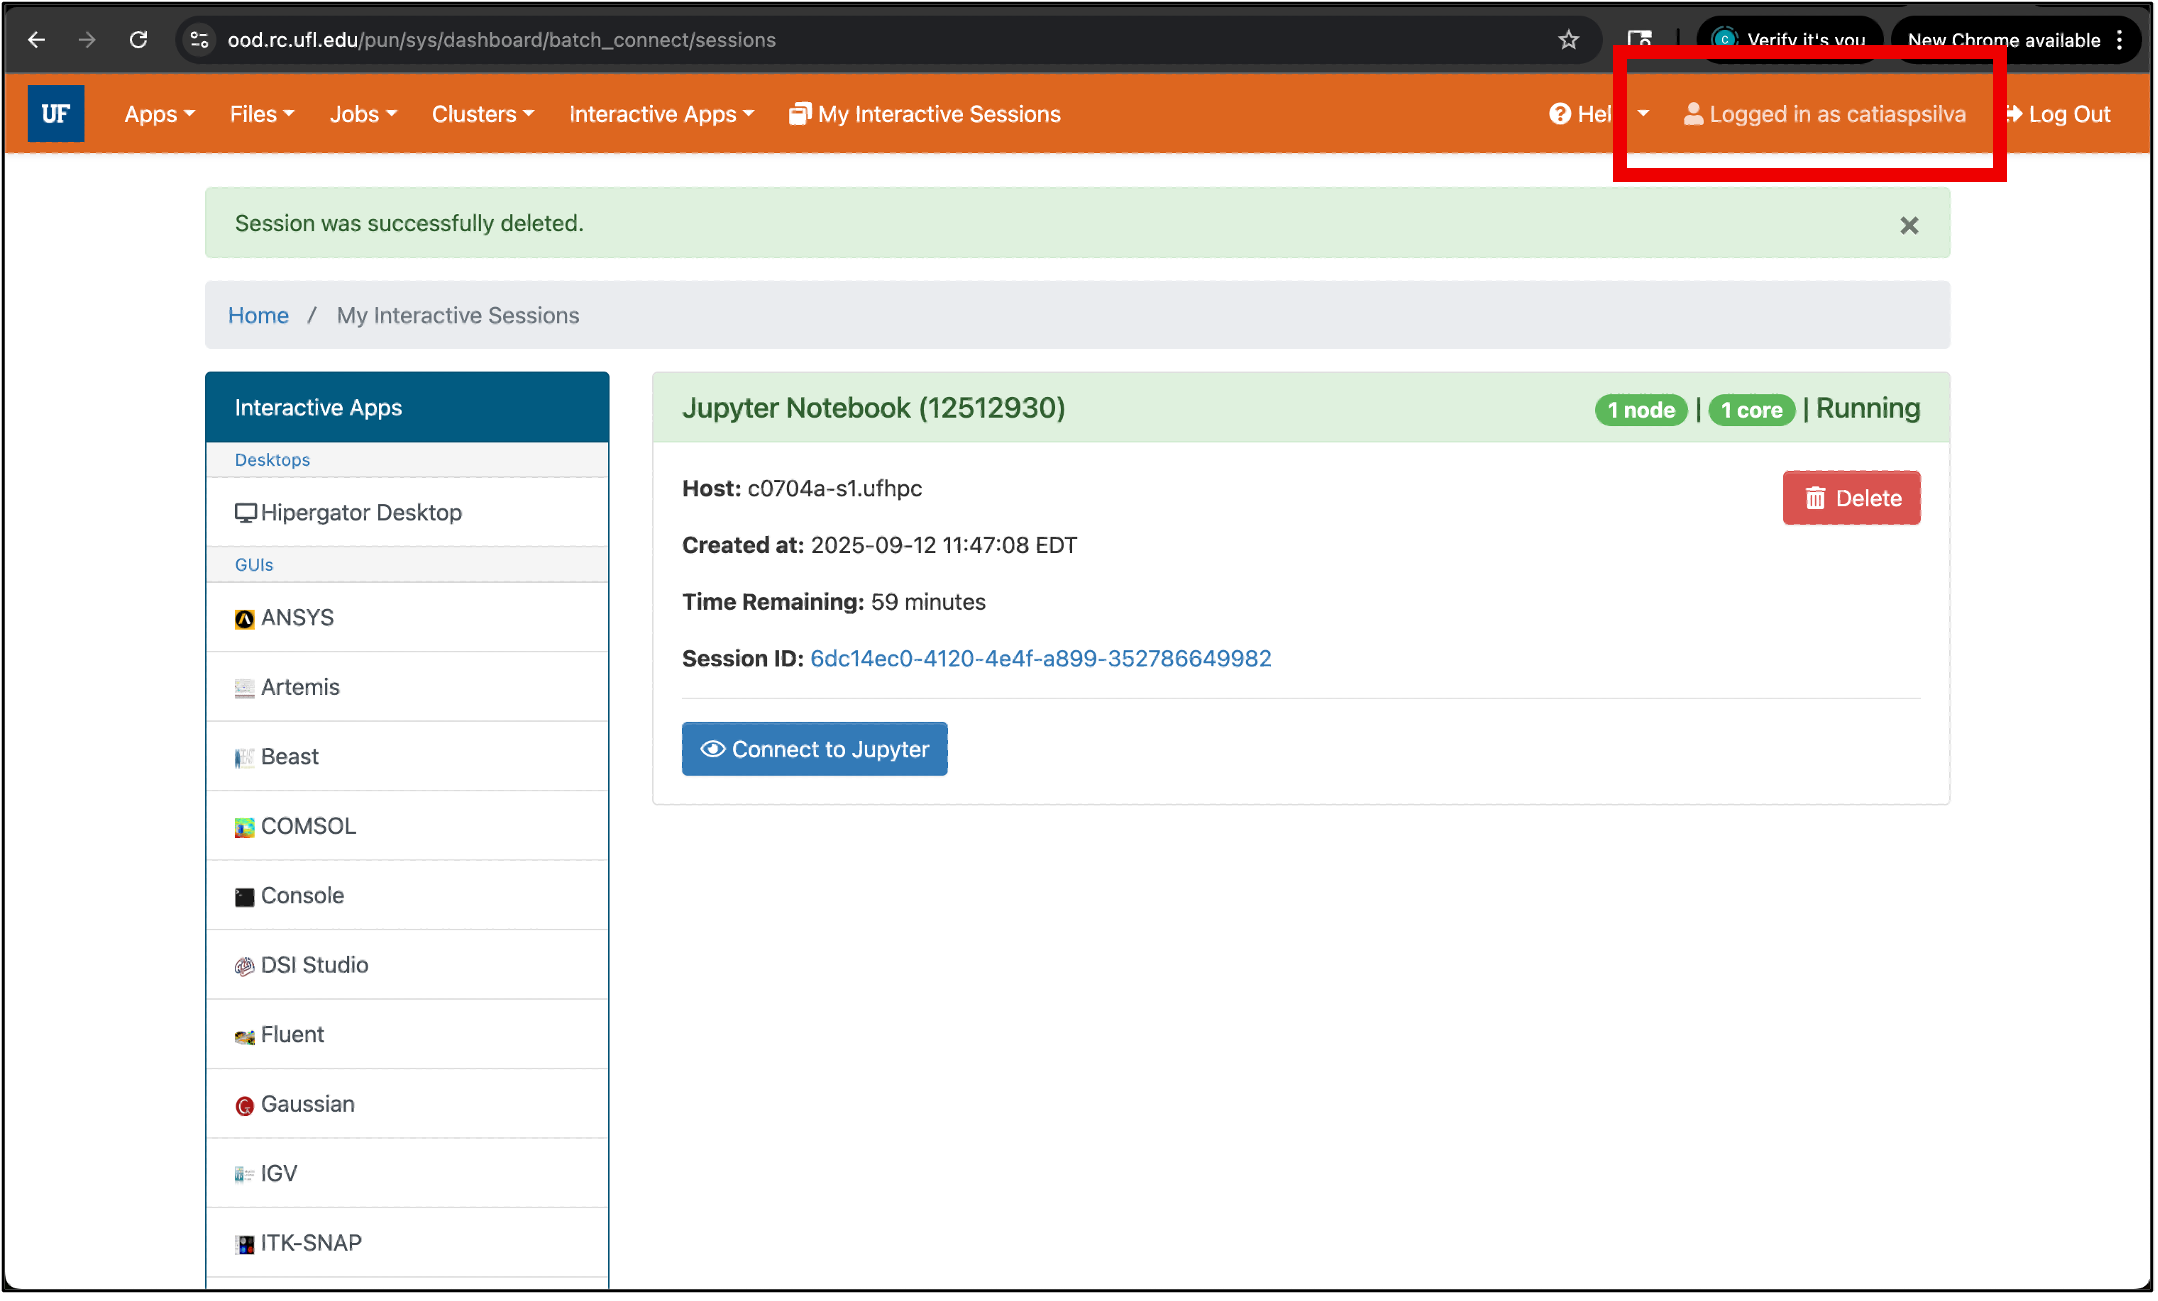

In [1]:
from IPython.display import Image
Image('figures/ood_job_request.png', width=900)

2. (0.5 points) **Create a symbolic link to map the class blue directory in your homepage. Attach a screenshot to show that this link has been created. Example and instructions below.**

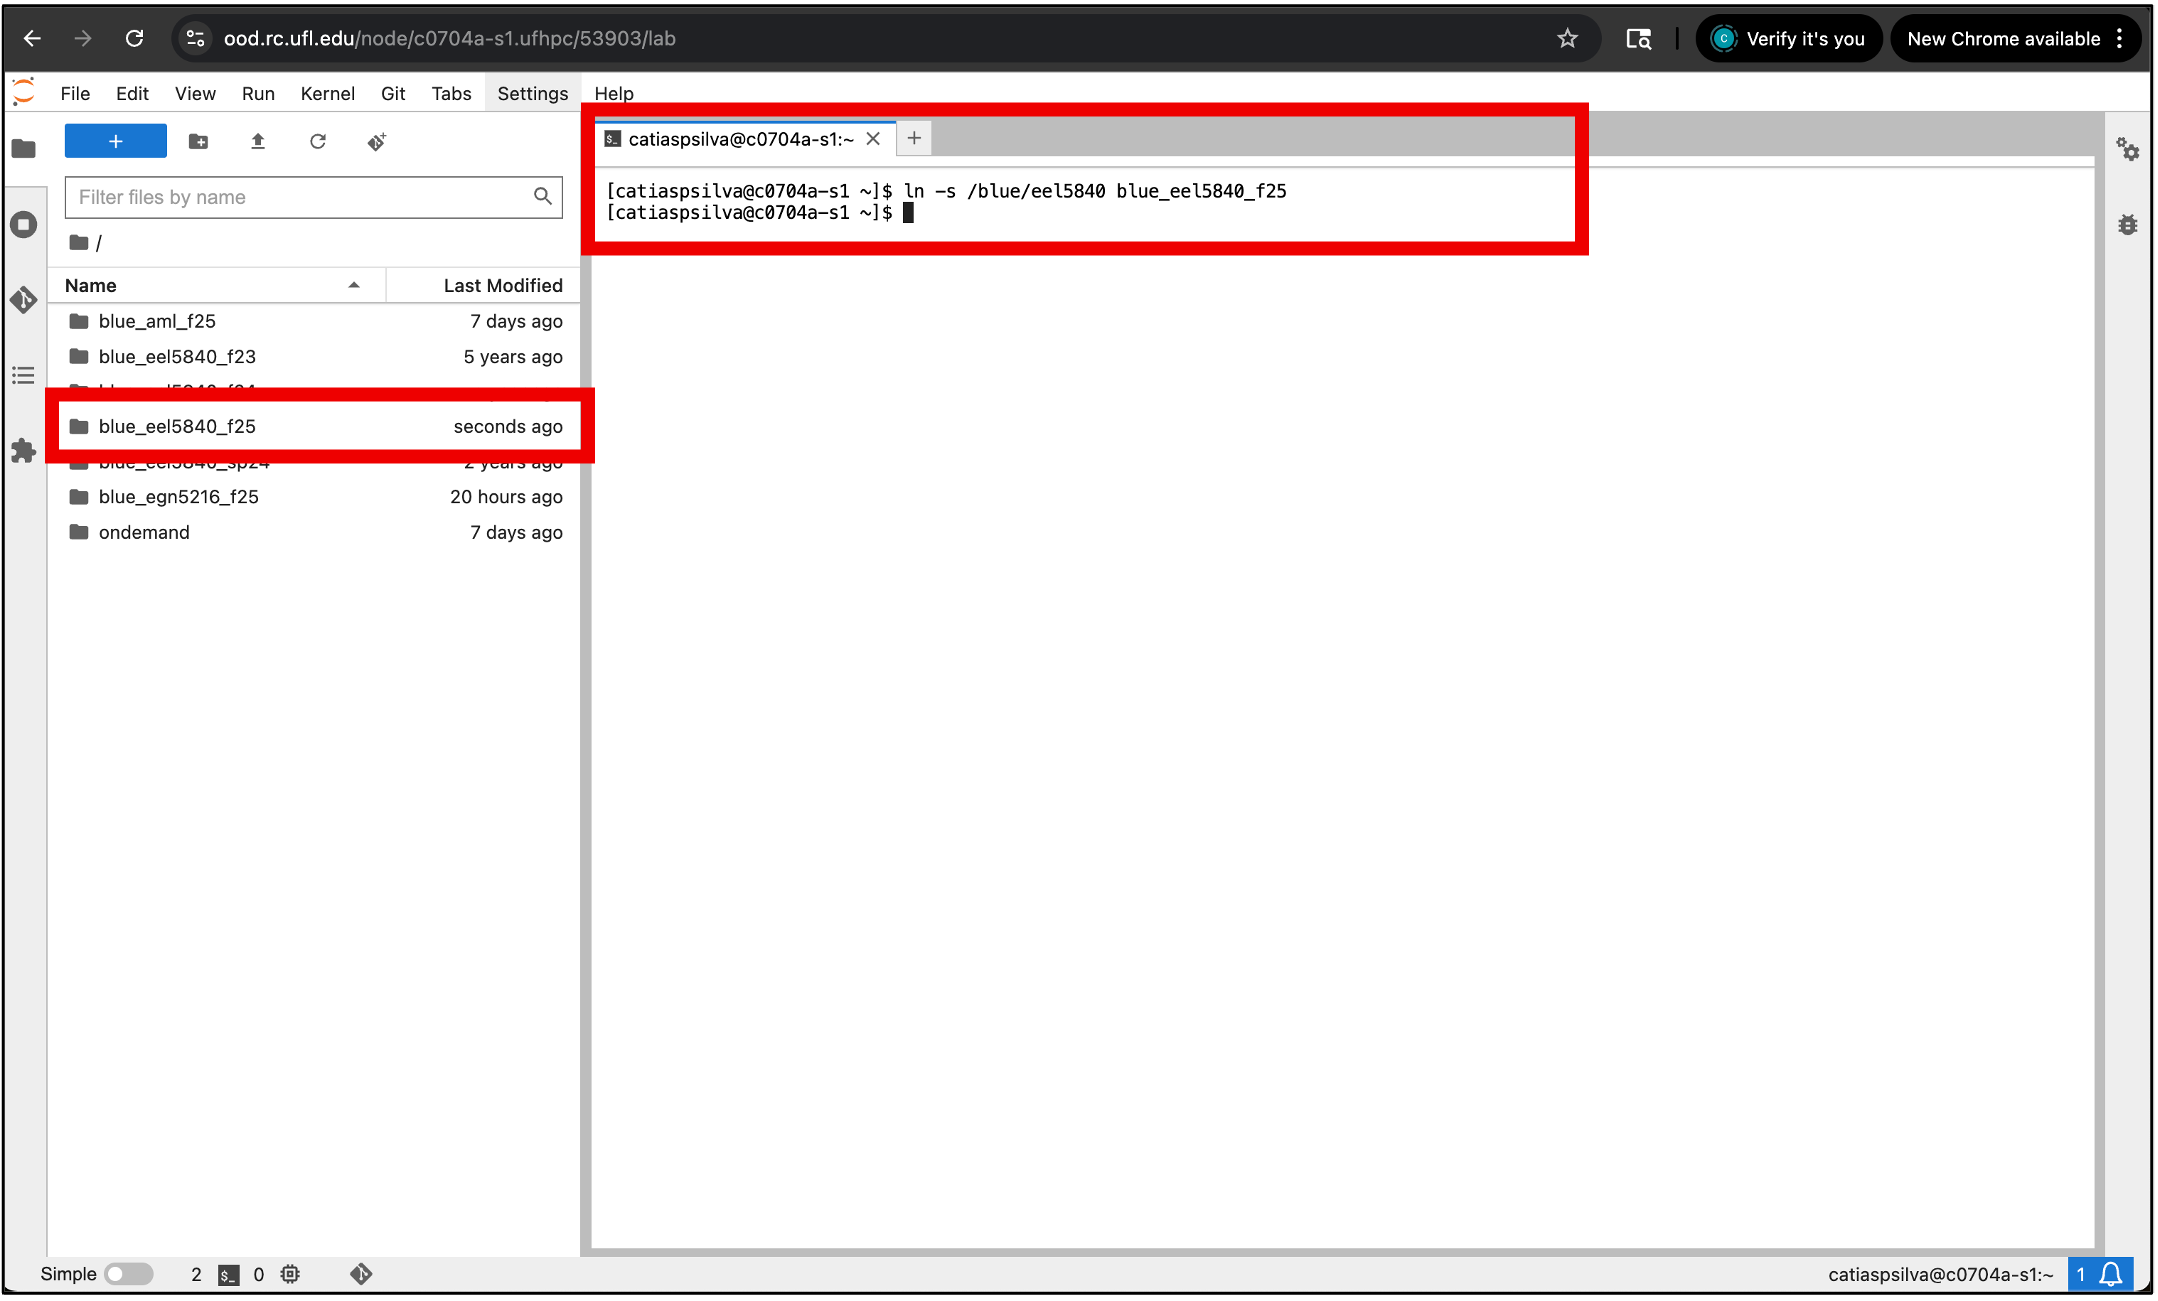

In [2]:
Image('figures/symbolic_link.png', width=900)

3. (1 point) **Using a terminal shell, change the directory to the _eel5840_ group. Using my naming convention, you would run ```cd blue_eel5840_f25/```. Next, if you don't see a folder with your GatorLink username, go ahead and create one (run ````mkdir folder_name````). Finally make sure your folder is only accessible to you by changing its mode to 700 (run ````chmod 700 folder_name````). Attach a screenshot with these steps. See example and instructions below.**

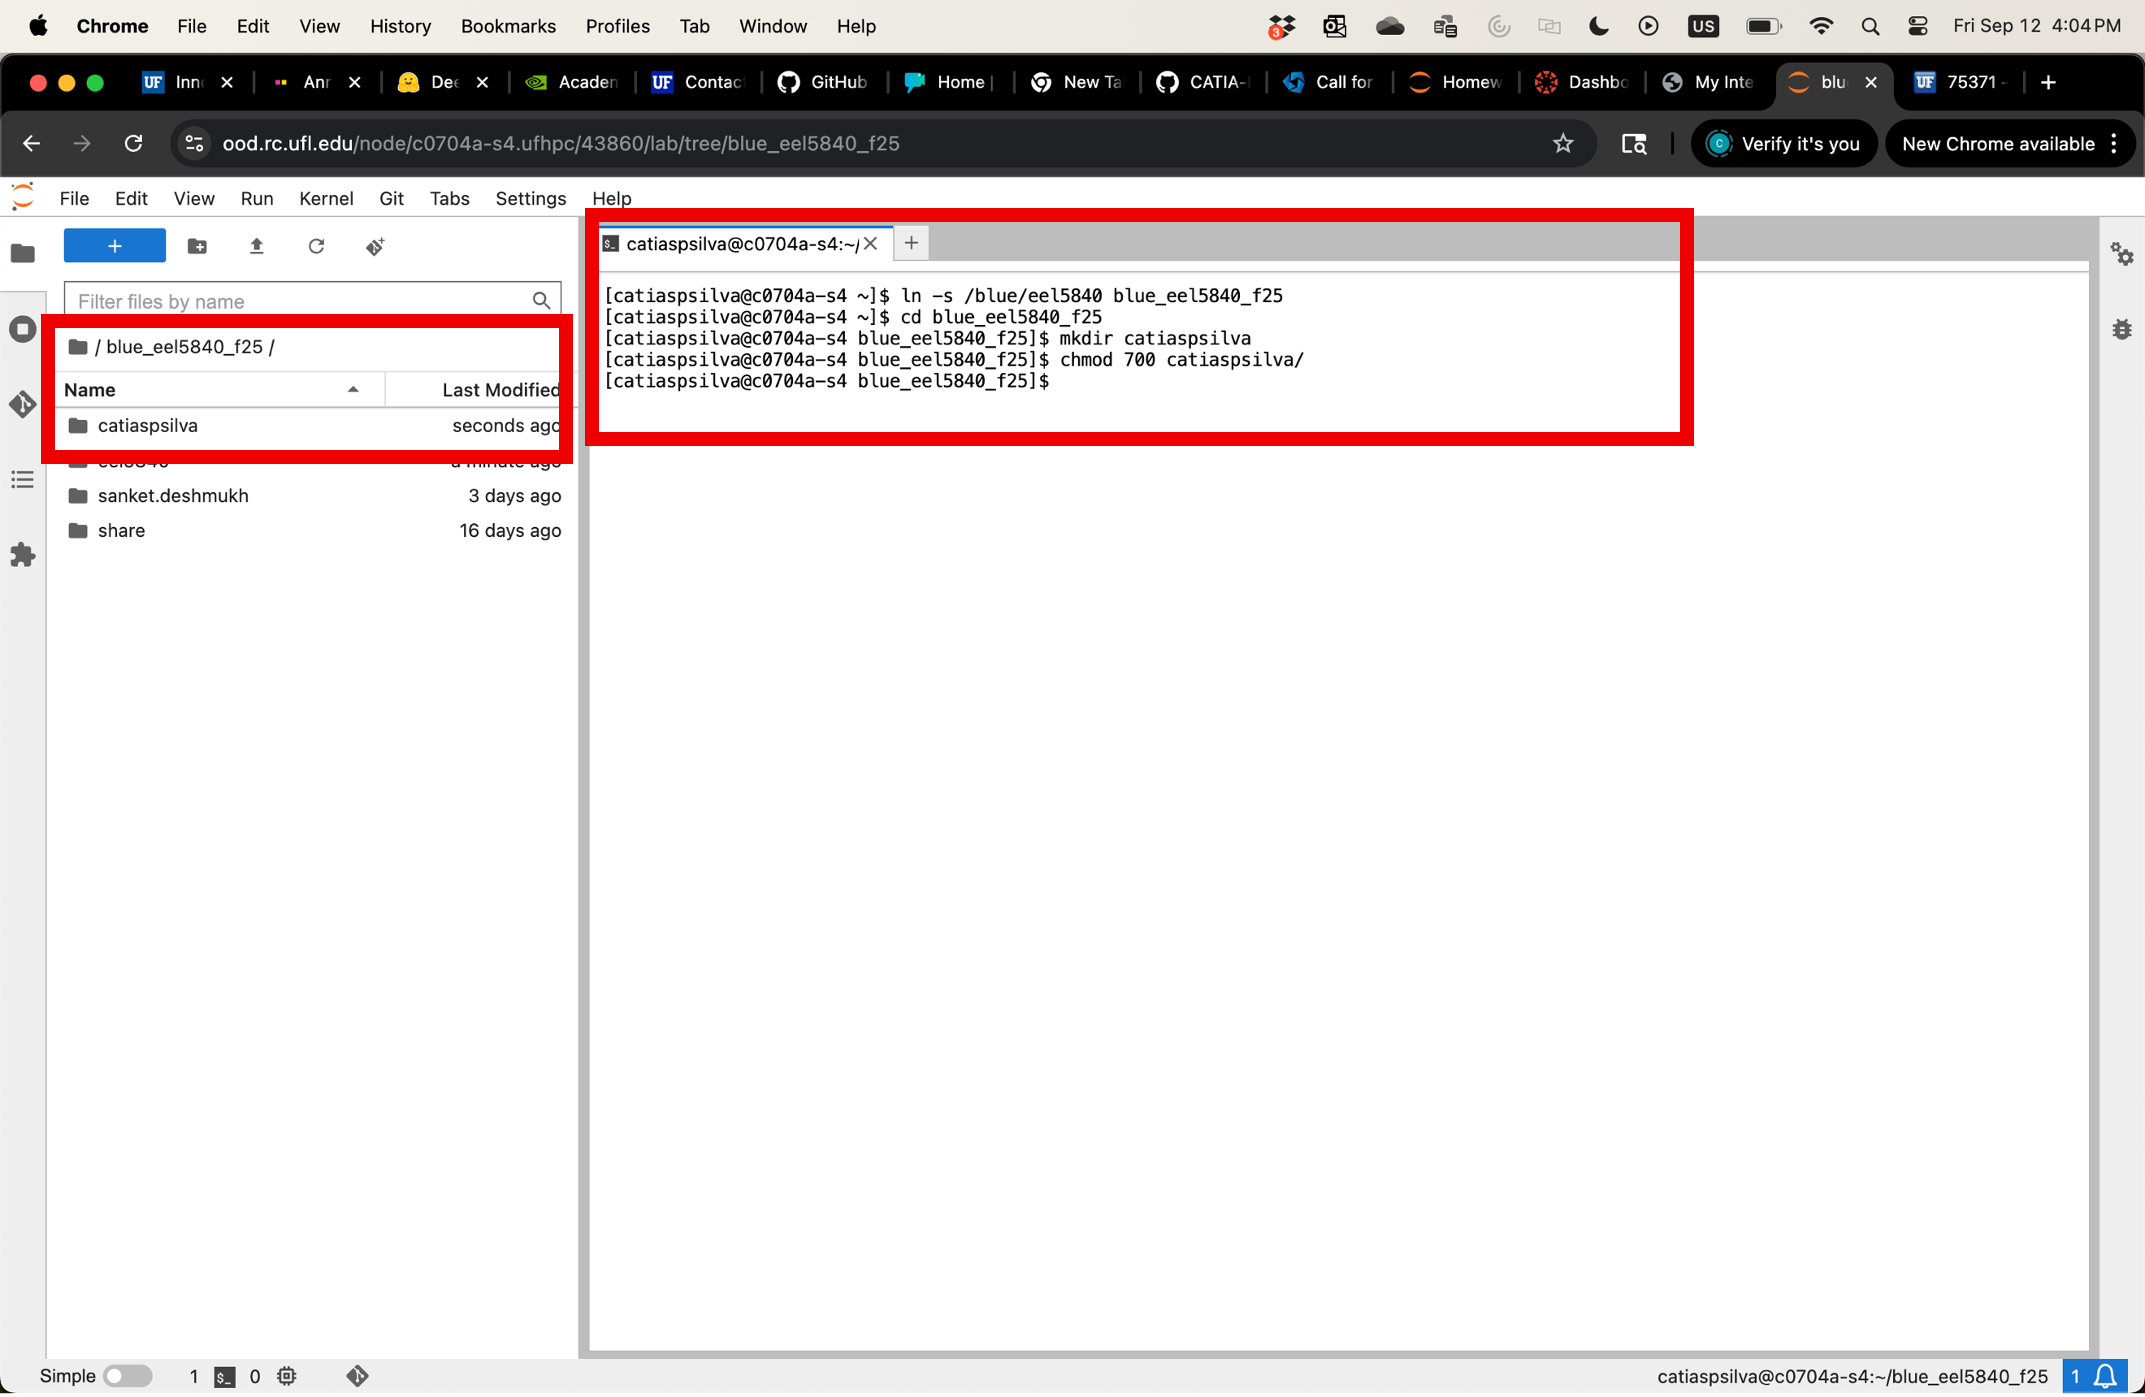

In [3]:
Image('figures/chmod700.png', width=900)

4. (1 point) **In the terminal change the directory to your folder (````cd folder_name/````), for me it's ```cd catiaspsilva/```. This is where you will clone ALL assignments. Set up your GitHub SSH key, and clone your quiz 2 repository. Attach a screenshot with this step. See example and instructions below for cloning the repository.**

**For instructions on setting up your GitHub SSH key, enroll in [this workshop](https://ufl.instructure.com/enroll/TWR9LR), select Module 3, and watch the 11-min video titled "Set up SSH Key" for a step-by-step hands-on demonstration.**

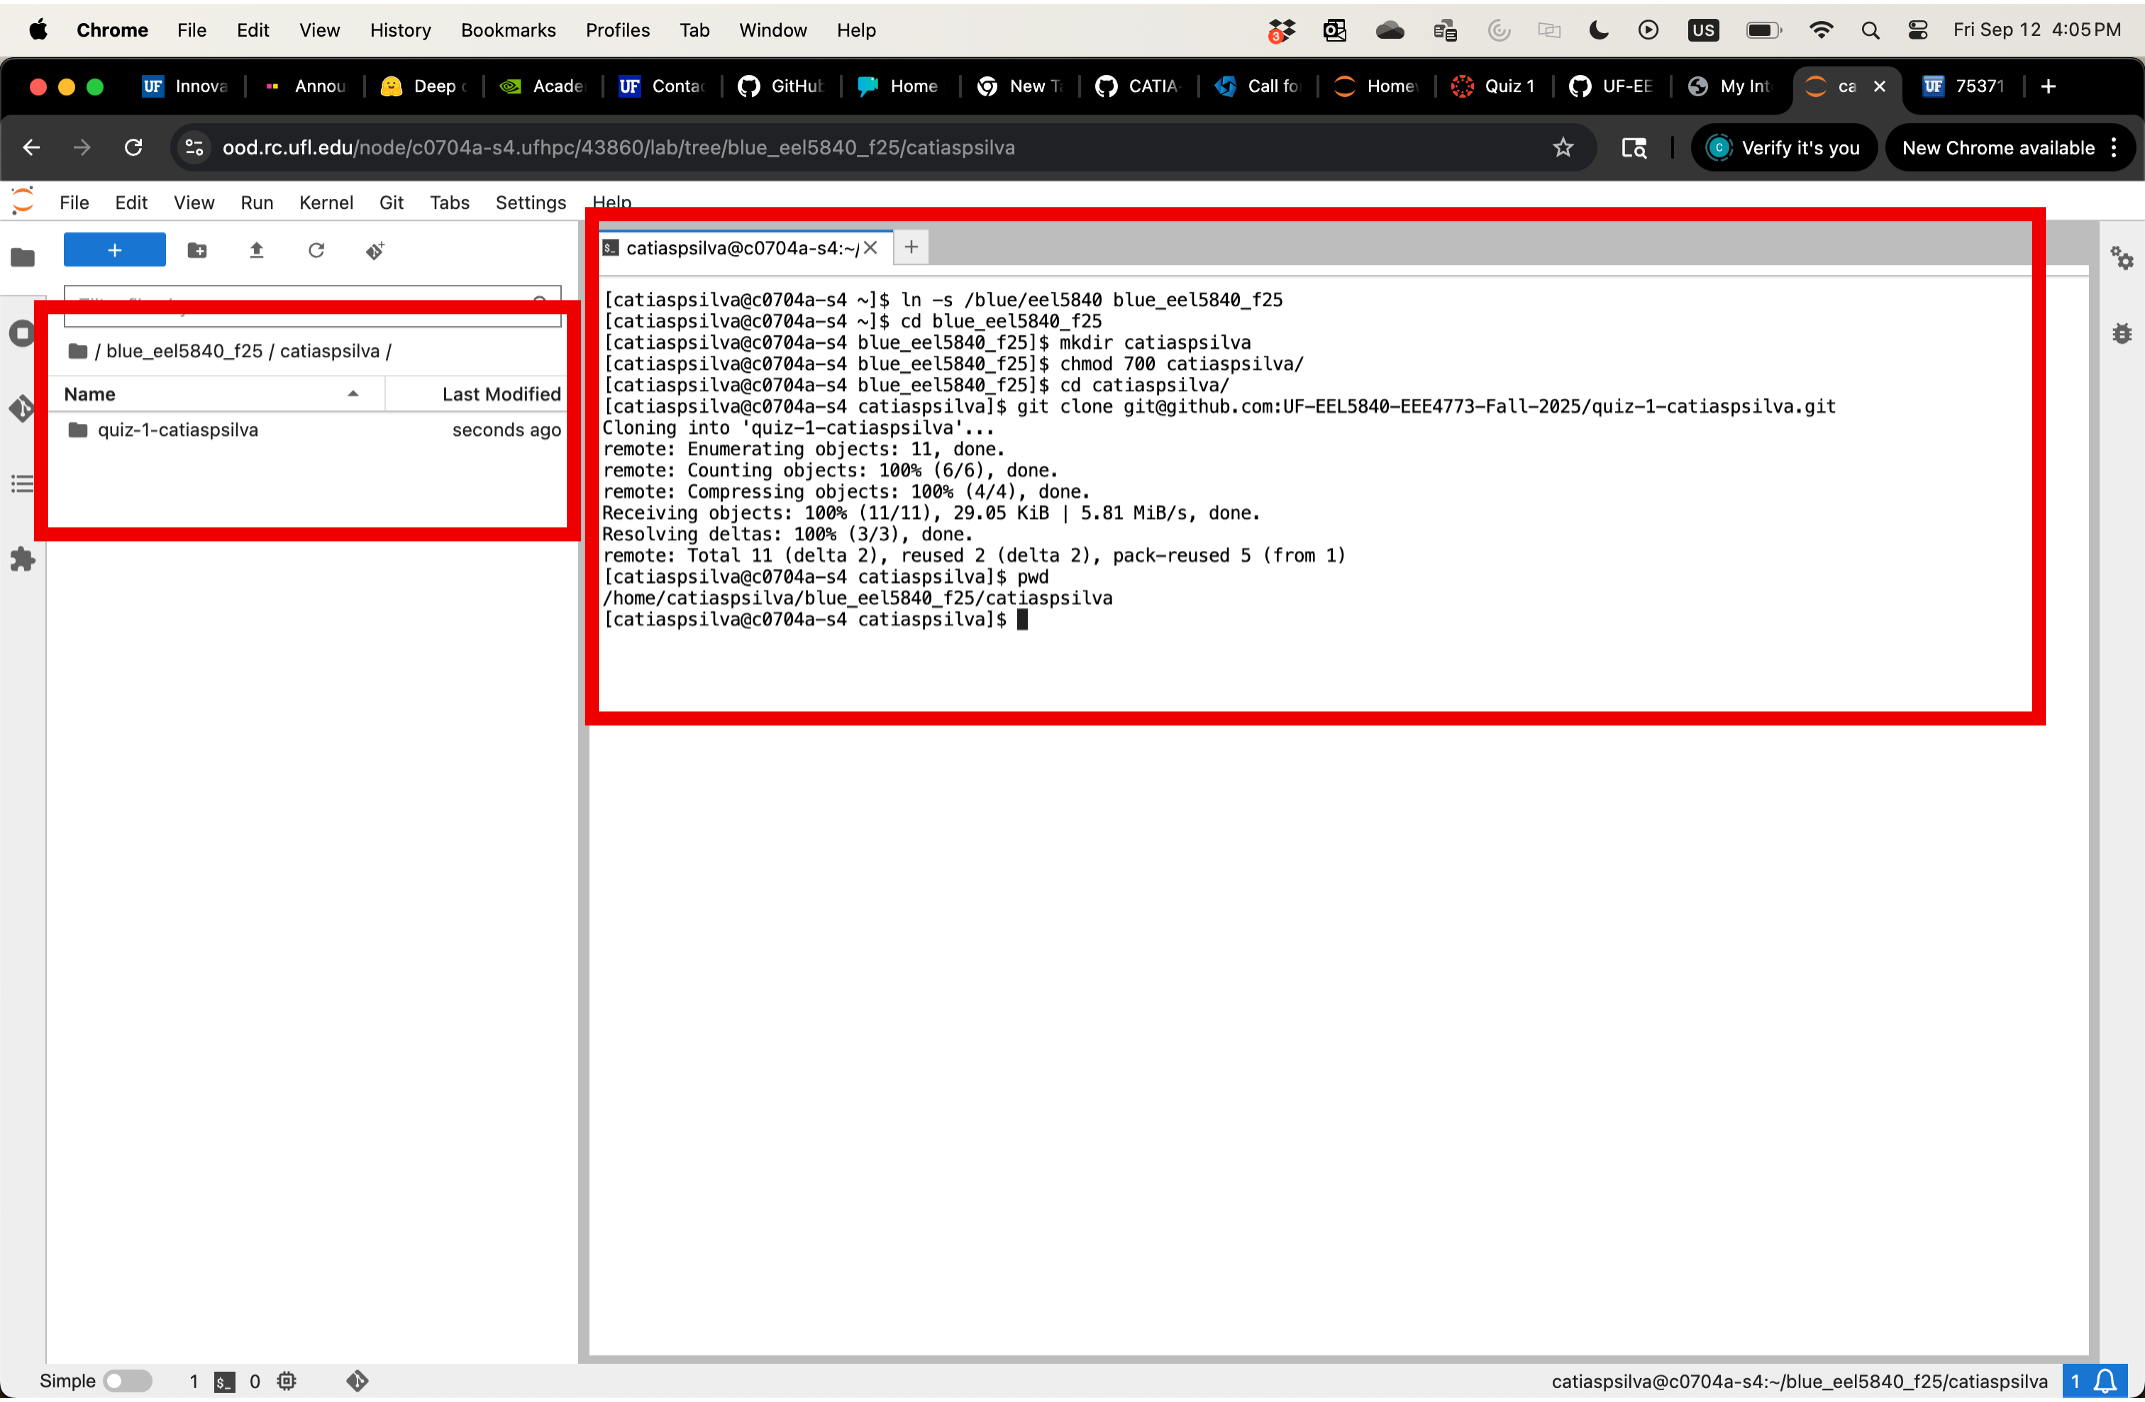

In [4]:
Image('figures/cloning_repo.png', width=900)

---